In [175]:
import pandas as pd
CORE = pd.read_csv('core.csv')
CORE.head()

,Employee Name,Employee Number,State,Zip,DOB,Age,Sex,MaritalDesc,CitizenDesc,Hispanic/Latino,...,Date of Hire,Date of Termination,Reason For Term,Employment Status,Department,Position,Pay Rate,Manager Name,Employee Source,Performance Score
0,"Brown, Mia",1.103024e+09,MA,1450.0,11/24/1985,32.0,Female,Married,US Citizen,No,...,10/27/2008,NaN,N/A - still employed,Active,Admin Offices,Accountant I,28.50,Brandon R. LeBlanc,Diversity Job Fair,Fully Meets
1,"LaRotonda, William",1.106027e+09,MA,1460.0,4/26/1984,33.0,Male,Divorced,US Citizen,No,...,1/6/2014,NaN,N/A - still employed,Active,Admin Offices,Accountant I,23.00,Brandon R. LeBlanc,Website Banner Ads,Fully Meets
2,"Steans, Tyrone",1.302053e+09,MA,2703.0,9/1/1986,31.0,Male,Single,US Citizen,No,...,9/29/2014,NaN,N/A - still employed,Active,Admin Offices,Accountant I,29.00,Brandon R. LeBlanc,Internet Search,Fully Meets
3,"Howard, Estelle",1.211051e+09,MA,2170.0,9/16/1985,32.0,Female,Married,US Citizen,No,...,2/16/2015,4/15/2015,N/A - still employed,Active,Admin Offices,Administrative Assistant,21.50,Brandon R. LeBlanc,Pay Per Click - Google,N/A- too early to review
4,"Singh, Nan",1.307060e+09,MA,2330.0,5/19/1988,29.0,Female,Single,US Citizen,No,...,5/1/2015,NaN,N/A - still employed,Active,Admin Offices,Administrative Assistant,16.56,Brandon R. LeBlanc,Website Banner Ads,N/A- too early to review


In [247]:
from sklearn.model_selection import train_test_split

# Cargar la base original completa
CORE_raw = pd.read_csv('CORE.csv')

# Dividir 90% para trabajar/desarrollar y 10% para prueba futura
CORE_train, CORE_test = train_test_split(CORE_raw, test_size=0.10, random_state=42)

print("Registros para desarrollo (90%):", CORE_train.shape)
print("Registros guardados para prueba (10%):", CORE_test.shape)

Registros para desarrollo (90%): (271, 21)
Registros guardados para prueba (10%): (31, 21)


In [177]:
# Convertir todos los nombres de las columnas a MAYÚSCULAS
CORE.columns = CORE.columns.str.upper()

# Convertir todos los datos de texto (columnas tipo object/string) a MAYÚSCULAS
for col in CORE.select_dtypes(include=['object', 'string']).columns:
    CORE[col] = CORE[col].astype(str).str.upper().str.strip()

# Verificar el resultado
print("Columnas en mayúsculas:", CORE.columns.tolist())
CORE.head()

Columnas en mayúsculas: ['EMPLOYEE NAME', 'EMPLOYEE NUMBER', 'STATE', 'ZIP', 'DOB', 'AGE', 'SEX', 'MARITALDESC', 'CITIZENDESC', 'HISPANIC/LATINO', 'RACEDESC', 'DATE OF HIRE', 'DATE OF TERMINATION', 'REASON FOR TERM', 'EMPLOYMENT STATUS', 'DEPARTMENT', 'POSITION', 'PAY RATE', 'MANAGER NAME', 'EMPLOYEE SOURCE', 'PERFORMANCE SCORE']


,EMPLOYEE NAME,EMPLOYEE NUMBER,STATE,ZIP,DOB,AGE,SEX,MARITALDESC,CITIZENDESC,HISPANIC/LATINO,...,DATE OF HIRE,DATE OF TERMINATION,REASON FOR TERM,EMPLOYMENT STATUS,DEPARTMENT,POSITION,PAY RATE,MANAGER NAME,EMPLOYEE SOURCE,PERFORMANCE SCORE
0,"BROWN, MIA",1.103024e+09,MA,1450.0,11/24/1985,32.0,FEMALE,MARRIED,US CITIZEN,NO,...,10/27/2008,NAN,N/A - STILL EMPLOYED,ACTIVE,ADMIN OFFICES,ACCOUNTANT I,28.50,BRANDON R. LEBLANC,DIVERSITY JOB FAIR,FULLY MEETS
1,"LAROTONDA, WILLIAM",1.106027e+09,MA,1460.0,4/26/1984,33.0,MALE,DIVORCED,US CITIZEN,NO,...,1/6/2014,NAN,N/A - STILL EMPLOYED,ACTIVE,ADMIN OFFICES,ACCOUNTANT I,23.00,BRANDON R. LEBLANC,WEBSITE BANNER ADS,FULLY MEETS
2,"STEANS, TYRONE",1.302053e+09,MA,2703.0,9/1/1986,31.0,MALE,SINGLE,US CITIZEN,NO,...,9/29/2014,NAN,N/A - STILL EMPLOYED,ACTIVE,ADMIN OFFICES,ACCOUNTANT I,29.00,BRANDON R. LEBLANC,INTERNET SEARCH,FULLY MEETS
3,"HOWARD, ESTELLE",1.211051e+09,MA,2170.0,9/16/1985,32.0,FEMALE,MARRIED,US CITIZEN,NO,...,2/16/2015,4/15/2015,N/A - STILL EMPLOYED,ACTIVE,ADMIN OFFICES,ADMINISTRATIVE ASSISTANT,21.50,BRANDON R. LEBLANC,PAY PER CLICK - GOOGLE,N/A- TOO EARLY TO REVIEW
4,"SINGH, NAN",1.307060e+09,MA,2330.0,5/19/1988,29.0,FEMALE,SINGLE,US CITIZEN,NO,...,5/1/2015,NAN,N/A - STILL EMPLOYED,ACTIVE,ADMIN OFFICES,ADMINISTRATIVE ASSISTANT,16.56,BRANDON R. LEBLANC,WEBSITE BANNER ADS,N/A- TOO EARLY TO REVIEW


In [178]:
CORE.dtypes

EMPLOYEE NAME           object
EMPLOYEE NUMBER        float64
STATE                   object
ZIP                    float64
DOB                     object
AGE                    float64
SEX                     object
MARITALDESC             object
CITIZENDESC             object
HISPANIC/LATINO         object
RACEDESC                object
DATE OF HIRE            object
DATE OF TERMINATION     object
REASON FOR TERM         object
EMPLOYMENT STATUS       object
DEPARTMENT              object
POSITION                object
PAY RATE               float64
MANAGER NAME            object
EMPLOYEE SOURCE         object
PERFORMANCE SCORE       object
dtype: object

In [180]:
col_numericas = ['EMPLOYEE NUMBER', 'ZIP', 'AGE', 'PAY RATE']
reporte_errores = []

for col in col_numericas:
    # Evalúa la columna de forma 100% independiente
    es_invalido = pd.to_numeric(CORE[col], errors='coerce').isna()
    
    # Extrae las filas que fallaron en ESTA columna
    for idx, valor in CORE[es_invalido][col].items():
        reporte_errores.append({
            'Fila_Index': idx,
            'Empleado': CORE.loc[idx, 'EMPLOYEE NAME'],
            'Columna_Con_Error': col,
            'Valor_Encontrado': valor
        })

# Convertir a tabla para visualización limpia
CORE_reporte = pd.DataFrame(reporte_errores)
CORE_reporte

,Fila_Index,Empleado,Columna_Con_Error,Valor_Encontrado
0,301,NAN,EMPLOYEE NUMBER,NaN
1,301,NAN,ZIP,NaN
2,301,NAN,AGE,NaN
3,301,NAN,PAY RATE,NaN


In [181]:
CORE.loc[301]

EMPLOYEE NAME          NAN
EMPLOYEE NUMBER        NaN
STATE                  NAN
ZIP                    NaN
DOB                    NAN
AGE                    NaN
SEX                    NAN
MARITALDESC            NAN
CITIZENDESC            NAN
HISPANIC/LATINO        NAN
RACEDESC               NAN
DATE OF HIRE           NAN
DATE OF TERMINATION    NAN
REASON FOR TERM        NAN
EMPLOYMENT STATUS      NAN
DEPARTMENT             NAN
POSITION               NAN
PAY RATE               NaN
MANAGER NAME           NAN
EMPLOYEE SOURCE        NAN
PERFORMANCE SCORE      NAN
Name: 301, dtype: object

In [182]:
# Ver el número total de filas de datos
print("Total de registros:", len(CORE))

# Ver el último registro de tu base de datos
CORE.tail(1)

Total de registros: 302


,EMPLOYEE NAME,EMPLOYEE NUMBER,STATE,ZIP,DOB,AGE,SEX,MARITALDESC,CITIZENDESC,HISPANIC/LATINO,...,DATE OF HIRE,DATE OF TERMINATION,REASON FOR TERM,EMPLOYMENT STATUS,DEPARTMENT,POSITION,PAY RATE,MANAGER NAME,EMPLOYEE SOURCE,PERFORMANCE SCORE
301,NAN,NaN,NAN,NaN,NAN,NaN,NAN,NAN,NAN,NAN,...,NAN,NAN,NAN,NAN,NAN,NAN,NaN,NAN,NAN,NAN


In [183]:
# Eliminar filas nulas
CORE = CORE.drop(index=301)

In [168]:
# Ver todos los valores únicos (la lista completa)
df['EMPLOYEE NAME'].unique()

# Ver el conteo de registros únicos
df['EMPLOYEE NAME'].nunique()

# Ver el conteo total de filas (incluyendo duplicados)
df['EMPLOYEE NAME'].count()

301

In [184]:
# 1. Limpiar espacios en blanco en los NOMBRES de las columnas
CORE.columns = CORE.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# 2. Limpiar espacios en blanco dentro de los DATOS de tipo texto (object)
cols_texto = CORE.select_dtypes(include=['object']).columns

for col in cols_texto:
    CORE[col] = CORE[col].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

In [185]:
# 1. Imputación de variables NUMÉRICAS con la MEDIANA
cols_numericas = CORE.select_dtypes(include=['float64', 'int64']).columns

for col in cols_numericas:
    if CORE[col].isna().sum() > 0:
        mediana = CORE[col].median()
        CORE[col] = CORE[col].fillna(mediana)

# 2. Imputación de variables CATEGÓRICAS con la MODA
cols_categoricas = CORE.select_dtypes(include=['object', 'category']).columns

for col in cols_categoricas:
    if CORE[col].isna().sum() > 0:
        moda = CORE[col].mode()[0]
        CORE[col] = CORE[col].fillna(moda)

# Confirmar que ya no hay valores nulos
print("Nulos restantes en la base:", CORE.isna().sum().sum())

Nulos restantes en la base: 0


In [186]:
# Lista columnas a eliminar
cols_a_eliminar = [
    'EMPLOYEE NAME', 
    'EMPLOYEE NUMBER', 
    'DOB', 
    'REASON FOR TERM', 
    'MANAGER NAME',
    'RACEDESC',
    'MARITALDESC',
    'CITIZENDESC',
    'EMPLOYMENT STATUS',
    'HISPANIC/LATINO',
    'ZIP'
]

# Eliminar las columnas del DataFrame
CORE = CORE.drop(columns=cols_a_eliminar, errors='ignore')

# Verificar las columnas restantes
print("Columnas conservadas en el dataset:", len(CORE.columns))
print(CORE.columns.tolist())

Columnas conservadas en el dataset: 10
['STATE', 'AGE', 'SEX', 'DATE OF HIRE', 'DATE OF TERMINATION', 'DEPARTMENT', 'POSITION', 'PAY RATE', 'EMPLOYEE SOURCE', 'PERFORMANCE SCORE']


In [187]:
# Mapeo ordinal basado en los valores reales del archivo
PERFORMANCE_MAP = {
    'PIP': 1,                         # Desempeño más bajo
    'Needs Improvement': 2,           # Necesita mejorar
    '90-day meets': 3,               # Cumple periodo inicial
    'N/A- too early to review': 4,    # Empleados nuevos
    'Fully Meets': 5,                 # Cumple expectativas
    'Exceeds': 6,                     # Supera expectativas
    'Exceptional': 7                  # Desempeño sobresaliente
}

# Aplicar el mapeo a la columna usando el nombre correcto del diccionario
CORE['PERFORMANCE SCORE'] = CORE['PERFORMANCE SCORE'].map(PERFORMANCE_MAP)

In [188]:
# One-Hot Encoding 
cols_categoricas = [
    'SEX',
]
CORE['SEX'] = CORE['SEX'].astype(str)

# Al poner drop_first=False se conservan todas las categorías
CORE_encoded = pd.get_dummies(CORE, columns=cols_categoricas, drop_first=False, dtype=int)

In [189]:
# 1. Verificar la forma (filas, columnas)
print("Dimensiones antes:", CORE.shape)
print("Dimensiones después:", CORE_encoded.shape)

# 2. Confirmar los tipos de datos en la base codificada
print("\nTipos de datos restantes:")
print(CORE_encoded.dtypes.value_counts())

# 3. Ver las primeras 5 filas de las nuevas columnas binarias creadas para SEX
cols_sex = [col for col in CORE_encoded.columns if col.startswith('SEX_')]
print("\nMuestra de las nuevas columnas de SEX (0 y 1):")
display(CORE_encoded[cols_sex].head())

# 4. Validación cruzada de una de las columnas (ejemplo: SEX_F o SEX_M)
col_test = cols_sex[0] if cols_sex else None
if col_test:
    print(f"\nValidación cruzada de '{col_test}':")
    print(CORE_encoded[col_test].value_counts())

Dimensiones antes: (301, 10)
Dimensiones después: (301, 11)

Tipos de datos restantes:
object     6
float64    3
int32      2
Name: count, dtype: int64

Muestra de las nuevas columnas de SEX (0 y 1):


,SEX_FEMALE,SEX_MALE
0,1,0
1,0,1
2,0,1
3,1,0
4,1,0



Validación cruzada de 'SEX_FEMALE':
SEX_FEMALE
1    174
0    127
Name: count, dtype: int64


In [228]:
AUS = pd.read_csv('ausentismo.csv')
AUS.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26.0,7.0,3,1,289.0,36.0,13.0,33.0,"239,554",...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,4.0
1,36,0.0,7.0,3,1,118.0,13.0,18.0,50.0,"239,554",...,1.0,1.0,1.0,1.0,0.0,0.0,98.0,178.0,31.0,0.0
2,3,23.0,7.0,4,1,179.0,51.0,18.0,38.0,"239,554",...,0.0,1.0,0.0,1.0,0.0,0.0,89.0,170.0,31.0,2.0
3,7,7.0,7.0,5,1,279.0,5.0,14.0,39.0,"239,554",...,0.0,1.0,2.0,1.0,1.0,0.0,68.0,168.0,24.0,4.0
4,11,23.0,7.0,5,1,289.0,36.0,13.0,33.0,"239,554",...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,2.0


In [229]:
# Convertir todos los nombres de las columnas a MAYÚSCULAS
AUS.columns = AUS.columns.str.upper()

# Convertir todos los datos de texto (columnas tipo object/string) a MAYÚSCULAS
for col in AUS.select_dtypes(include=['object', 'string']).columns:
    AUS[col] = AUS[col].astype(str).str.upper().str.strip()

# Verificar el resultado
print("Columnas en mayúsculas:", AUS.columns.tolist())
AUS.head()

Columnas en mayúsculas: ['ID', 'REASON FOR ABSENCE', 'MONTH OF ABSENCE', 'DAY OF THE WEEK', 'SEASONS', 'TRANSPORTATION EXPENSE', 'DISTANCE FROM RESIDENCE TO WORK', 'SERVICE TIME', 'AGE', 'WORK LOAD AVERAGE/DAY ', 'HIT TARGET', 'DISCIPLINARY FAILURE', 'EDUCATION', 'SON', 'SOCIAL DRINKER', 'SOCIAL SMOKER', 'PET', 'WEIGHT', 'HEIGHT', 'BODY MASS INDEX', 'ABSENTEEISM TIME IN HOURS']


,ID,REASON FOR ABSENCE,MONTH OF ABSENCE,DAY OF THE WEEK,SEASONS,TRANSPORTATION EXPENSE,DISTANCE FROM RESIDENCE TO WORK,SERVICE TIME,AGE,WORK LOAD AVERAGE/DAY,...,DISCIPLINARY FAILURE,EDUCATION,SON,SOCIAL DRINKER,SOCIAL SMOKER,PET,WEIGHT,HEIGHT,BODY MASS INDEX,ABSENTEEISM TIME IN HOURS
0,11,26.0,7.0,3,1,289.0,36.0,13.0,33.0,"239,554",...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,4.0
1,36,0.0,7.0,3,1,118.0,13.0,18.0,50.0,"239,554",...,1.0,1.0,1.0,1.0,0.0,0.0,98.0,178.0,31.0,0.0
2,3,23.0,7.0,4,1,179.0,51.0,18.0,38.0,"239,554",...,0.0,1.0,0.0,1.0,0.0,0.0,89.0,170.0,31.0,2.0
3,7,7.0,7.0,5,1,279.0,5.0,14.0,39.0,"239,554",...,0.0,1.0,2.0,1.0,1.0,0.0,68.0,168.0,24.0,4.0
4,11,23.0,7.0,5,1,289.0,36.0,13.0,33.0,"239,554",...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,2.0


In [230]:
AUS.dtypes

ID                                   int64
REASON FOR ABSENCE                 float64
MONTH OF ABSENCE                   float64
DAY OF THE WEEK                      int64
SEASONS                              int64
TRANSPORTATION EXPENSE             float64
DISTANCE FROM RESIDENCE TO WORK    float64
SERVICE TIME                       float64
AGE                                float64
WORK LOAD AVERAGE/DAY               object
HIT TARGET                         float64
DISCIPLINARY FAILURE               float64
EDUCATION                          float64
SON                                float64
SOCIAL DRINKER                     float64
SOCIAL SMOKER                      float64
PET                                float64
WEIGHT                             float64
HEIGHT                             float64
BODY MASS INDEX                    float64
ABSENTEEISM TIME IN HOURS          float64
dtype: object

In [231]:
# 1. Asegurar que los nombres de las columnas no tengan espacios extras y estén en mayúsculas
AUS.columns = AUS.columns.str.strip().str.upper()

# 2. Definir la lista exacta de variables seleccionadas
cols_seleccionadas = [
    'REASON FOR ABSENCE',
    'TRANSPORTATION EXPENSE',
    'DISTANCE FROM RESIDENCE TO WORK',
    'SERVICE TIME',
    'AGE',
    'WORK LOAD AVERAGE/DAY',
    'HIT TARGET',
    'DISCIPLINARY FAILURE',
    'SOCIAL DRINKER',
    'SOCIAL SMOKER',
    'BODY MASS INDEX'
]

# 3. Filtrar el DataFrame
AUS = AUS[cols_seleccionadas].copy()

# 4. Verificar el resultado
print("Nuevas dimensiones (filas, columnas):", AUS.shape)
AUS.head()

Nuevas dimensiones (filas, columnas): (740, 11)


,REASON FOR ABSENCE,TRANSPORTATION EXPENSE,DISTANCE FROM RESIDENCE TO WORK,SERVICE TIME,AGE,WORK LOAD AVERAGE/DAY,HIT TARGET,DISCIPLINARY FAILURE,SOCIAL DRINKER,SOCIAL SMOKER,BODY MASS INDEX
0,26.0,289.0,36.0,13.0,33.0,"239,554",97.0,0.0,1.0,0.0,30.0
1,0.0,118.0,13.0,18.0,50.0,"239,554",97.0,1.0,1.0,0.0,31.0
2,23.0,179.0,51.0,18.0,38.0,"239,554",97.0,0.0,1.0,0.0,31.0
3,7.0,279.0,5.0,14.0,39.0,"239,554",97.0,0.0,1.0,1.0,24.0
4,23.0,289.0,36.0,13.0,33.0,"239,554",97.0,0.0,1.0,0.0,30.0


In [232]:
# 1. Convertir la columna de carga de trabajo de texto a numérico (float)
AUS['WORK LOAD AVERAGE/DAY'] = (
    AUS['WORK LOAD AVERAGE/DAY']
    .astype(str)
    .str.replace(',', '.')
    .str.extract(r'([\d.]+)')[0]
    .astype(float)
)

# 2. Eliminar filas donde la variable objetivo 'REASON FOR ABSENCE' sea nula (solo son 3 filas)
AUS = AUS.dropna(subset=['REASON FOR ABSENCE']).reset_index(drop=True)

# 3. Imputación de variables NUMÉRICAS con la MEDIANA
cols_numericas = AUS.select_dtypes(include=['float64', 'int64']).columns

for col in cols_numericas:
    if AUS[col].isna().sum() > 0:
        mediana = AUS[col].median()
        AUS[col] = AUS[col].fillna(mediana)

# 4. Imputación de variables CATEGÓRICAS con la MODA (si existieran columnas tipo object)
cols_categoricas = AUS.select_dtypes(include=['object', 'category']).columns

for col in cols_categoricas:
    if AUS[col].isna().sum() > 0:
        moda = AUS[col].mode()[0]
        AUS[col] = AUS[col].fillna(moda)

# Confirmar resultado
print("Nulos restantes en la base:", AUS.isna().sum().sum())

Nulos restantes en la base: 0


In [233]:
# Conteo de nulos por columna
print("Valores nulos por columna:")
print(AUS.isnull().sum())

print("\nTotal de celdas nulas en la base:", AUS.isnull().sum().sum())

Valores nulos por columna:
REASON FOR ABSENCE                 0
TRANSPORTATION EXPENSE             0
DISTANCE FROM RESIDENCE TO WORK    0
SERVICE TIME                       0
AGE                                0
WORK LOAD AVERAGE/DAY              0
HIT TARGET                         0
DISCIPLINARY FAILURE               0
SOCIAL DRINKER                     0
SOCIAL SMOKER                      0
BODY MASS INDEX                    0
dtype: int64

Total de celdas nulas en la base: 0


In [234]:
print("Total de filas restantes:", len(AUS))

Total de filas restantes: 737


In [243]:
import pandas as pd

# 1. Cargar la base y pasar todo a mayúsculas
RET = pd.read_csv('retencion.csv')
RET.columns = RET.columns.str.strip().str.upper()

cols_texto = RET.select_dtypes(include=['object']).columns
for col in cols_texto:
    RET[col] = RET[col].astype(str).str.upper()

# 2. Definir columnas a descartar (IDs, constantes sin variabilidad y tarifas redundantes)
cols_a_eliminar = [
    'EMPLOYEENUMBER', 'EMPLOYEECOUNT', 'STANDARDHOURS','EDUCATIONFIELD', 'HOURLYRATE','JOBROLE', 'MARITALSTATUS', 'STANDARDHOURS',
    'STOCKOPTIONLEVEL','DAILYRATE', 'OVER18'
]

# 3. Filtrar el DataFrame final para el modelo
RET= RET.drop(columns=cols_a_eliminar).copy()

# Verificar estructura final
print("Estructura del dataset de predicción:", RET.shape)
RET.head()

Estructura del dataset de predicción: (1470, 25)


,AGE,ATTRITION,BUSINESSTRAVEL,DEPARTMENT,DISTANCEFROMHOME,EDUCATION,ENVIRONMENTSATISFACTION,GENDER,JOBINVOLVEMENT,JOBLEVEL,...,PERCENTSALARYHIKE,PERFORMANCERATING,RELATIONSHIPSATISFACTION,TOTALWORKINGYEARS,TRAININGTIMESLASTYEAR,WORKLIFEBALANCE,YEARSATCOMPANY,YEARSINCURRENTROLE,YEARSSINCELASTPROMOTION,YEARSWITHCURRMANAGER
0,41,YES,TRAVEL_RARELY,SALES,1,2,2,FEMALE,3,2,...,11,3,1,8,0,1,6,4,0,5
1,49,NO,TRAVEL_FREQUENTLY,RESEARCH & DEVELOPMENT,8,1,3,MALE,2,2,...,23,4,4,10,3,3,10,7,1,7
2,37,YES,TRAVEL_RARELY,RESEARCH & DEVELOPMENT,2,2,4,MALE,2,1,...,15,3,2,7,3,3,0,0,0,0
3,33,NO,TRAVEL_FREQUENTLY,RESEARCH & DEVELOPMENT,3,4,4,FEMALE,3,1,...,11,3,3,8,3,3,8,7,3,0
4,27,NO,TRAVEL_RARELY,RESEARCH & DEVELOPMENT,2,1,1,MALE,3,1,...,12,3,4,6,3,3,2,2,2,2


In [244]:
# Ver conteo de nulos por columna
print("Valores nulos por columna:")
print(RET_modelo.isnull().sum())

# Ver el total absoluto de nulos
print("\nTotal de celdas nulas en la base:", RET_modelo.isnull().sum().sum())

Valores nulos por columna:
AGE                         0
ATTRITION                   0
BUSINESSTRAVEL              0
DEPARTMENT                  0
DISTANCEFROMHOME            0
EDUCATION                   0
ENVIRONMENTSATISFACTION     0
GENDER                      0
JOBINVOLVEMENT              0
JOBLEVEL                    0
JOBSATISFACTION             0
MONTHLYINCOME               0
MONTHLYRATE                 0
NUMCOMPANIESWORKED          0
OVERTIME                    0
PERCENTSALARYHIKE           0
PERFORMANCERATING           0
RELATIONSHIPSATISFACTION    0
TOTALWORKINGYEARS           0
TRAININGTIMESLASTYEAR       0
WORKLIFEBALANCE             0
YEARSATCOMPANY              0
YEARSINCURRENTROLE          0
YEARSSINCELASTPROMOTION     0
YEARSWITHCURRMANAGER        0
dtype: int64

Total de celdas nulas en la base: 0


In [245]:
#. Mapeo para OVERTIME (Horas extra: YES -> 1, NO -> 0)
OVERTIME_MAP = {
    'NO': 0,     # No hace horas extra
    'YES': 1     # Sí hace horas extra
}

# Mapeo para ATTRITION (Variable Target: YES -> 1, NO -> 0)
ATTRITION_MAP = {
    'NO': 0,     # Empleado permanece en la empresa
    'YES': 1     # Empleado renuncia / deja la empresa
}

# Aplicar los mapeos a las columnas correspondientes
RET['OVERTIME'] = RET['OVERTIME'].str.upper().map(OVERTIME_MAP)
RET['ATTRITION'] = RET['ATTRITION'].str.upper().map(ATTRITION_MAP)

In [246]:
# 1. Confirmar que no queden valores vacíos (NaN)
print("Nulos en OVERTIME:", RET['OVERTIME'].isnull().sum())
print("Nulos en ATTRITION:", RET['ATTRITION'].isnull().sum())

# 2. Conteo final de frecuencias para OVERTIME
print("\nDistribución de OVERTIME (0: No, 1: Sí):")
print(RET['OVERTIME'].value_counts())

# 3. Conteo final de frecuencias para ATTRITION
print("\nDistribución de ATTRITION (0: Permanece, 1: Renuncia):")
print(RET['ATTRITION'].value_counts())

# 4. Vista previa de ambas columnas
display(RET[['OVERTIME', 'ATTRITION']].head())

Nulos en OVERTIME: 0
Nulos en ATTRITION: 0

Distribución de OVERTIME (0: No, 1: Sí):
OVERTIME
0    1054
1     416
Name: count, dtype: int64

Distribución de ATTRITION (0: Permanece, 1: Renuncia):
ATTRITION
0    1233
1     237
Name: count, dtype: int64


,OVERTIME,ATTRITION
0,1,1
1,0,0
2,1,1
3,1,0
4,0,0


In [259]:
#Pipeline CORE

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CARGAR DATOS ORIGINALES (CRUDOS)
# ==========================================
CORE_raw = pd.read_csv('CORE.csv')

# ==========================================
# 2. DIVISIÓN DE DATOS (90% / 10%)
# ==========================================
# Guardamos el 10% sin tocar antes de cualquier limpieza
CORE_train, CORE_test = train_test_split(CORE_raw, test_size=0.10, random_state=42)

print(f"Registros Desarrollo (90%): {CORE_train.shape[0]}")
print(f"Registros Prueba (10%): {CORE_test.shape[0]}")


# ==========================================
# 3. DEFINIR LA FUNCIÓN DE TRANSFORMACIÓN
# ==========================================
def transformar_CORE_pipeline(df):
    CORE = df.copy()
    
    # a) Mayúsculas y limpieza de espacios en columnas
    CORE.columns = CORE.columns.str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)
    
    # b) Mayúsculas y limpieza de espacios en texto
    cols_texto = CORE.select_dtypes(include=['object', 'string']).columns
    for col in cols_texto:
        CORE[col] = CORE[col].astype(str).str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)
    
    # c) Conversión de numéricas que vienen como texto
    col_numericas = ['EMPLOYEE NUMBER', 'ZIP', 'AGE', 'PAY RATE']
    for col in col_numericas:
        if col in CORE.columns:
            CORE[col] = pd.to_numeric(CORE[col], errors='coerce')
    
    # d) Imputación de nulos (Mediana / Moda)
    cols_num = CORE.select_dtypes(include=['float64', 'int64']).columns
    for col in cols_num:
        if CORE[col].isna().sum() > 0:
            CORE[col] = CORE[col].fillna(CORE[col].median())
            
    cols_cat = CORE.select_dtypes(include=['object', 'category']).columns
    for col in cols_cat:
        if CORE[col].isna().sum() > 0:
            CORE[col] = CORE[col].fillna(CORE[col].mode()[0])
            
    # e) Eliminar columnas innecesarias
    cols_a_eliminar = [
        'EMPLOYEE NAME', 'EMPLOYEE NUMBER', 'DOB', 'REASON FOR TERM', 
        'MANAGER NAME', 'RACEDESC', 'MARITALDESC', 'CITIZENDESC', 
        'EMPLOYMENT STATUS', 'HISPANIC/LATINO', 'ZIP'
    ]
    CORE = CORE.drop(columns=cols_a_eliminar, errors='ignore')
    
    # f) Mapeo Ordinal de PERFORMANCE SCORE
    PERFORMANCE_MAP = {
        'PIP': 1,
        'NEEDS IMPROVEMENT': 2,
        '90-DAY MEETS': 3,
        'N/A- TOO EARLY TO REVIEW': 4,
        'FULLY MEETS': 5,
        'EXCEEDS': 6,
        'EXCEPTIONAL': 7
    }
    if 'PERFORMANCE SCORE' in CORE.columns:
        CORE['PERFORMANCE SCORE'] = CORE['PERFORMANCE SCORE'].map(PERFORMANCE_MAP)
        

# g) One-Hot Encoding manual para SEX
    if 'SEX' in CORE.columns:
        # Limpieza de texto: extrae la primera letra ('F' o 'M')
        sex_limpio = CORE['SEX'].astype(str).str.strip().str.upper().str[0]
        
        # Creación explícita de ambas columnas binarias
        CORE['SEX_F'] = (sex_limpio == 'F').astype(int)
        CORE['SEX_M'] = (sex_limpio == 'M').astype(int)
        
        # Eliminar la columna original
        CORE = CORE.drop(columns=['SEX'])
        
    # h) Eliminar cualquier fila con nulos residuales
    CORE = CORE.dropna()
        
    return CORE


# ==========================================
# 4. CREAR EL PIPELINE DE SCIKIT-LEARN
# ==========================================
pipe_CORE = Pipeline(steps=[
    ('limpieza_y_transformacion', FunctionTransformer(transformar_CORE_pipeline))
])


# ==========================================
# 5. EJECUTAR EL PIPELINE
# ==========================================
# Procesar el 90% (Entrenamiento/Desarrollo)
CORE_train_procesado = pipe_CORE.fit_transform(CORE_train)

# Procesar el 10% (Prueba/Innovación a futuro)
CORE_test_procesado = pipe_CORE.transform(CORE_test)


# ==========================================
# 6. VALIDACIÓN DE RESULTADOS
# ==========================================
print("\n--- VALIDACIÓN FINAL ---")
print("Dimensiones 90% Limpio:", CORE_train_procesado.shape)
print("Dimensiones 10% Limpio:", CORE_test_procesado.shape)
print("Nulos restantes en 90%:", CORE_train_procesado.isna().sum().sum())
print("Nulos restantes en 10%:", CORE_test_procesado.isna().sum().sum())

display(CORE_train_procesado.head())

Registros Desarrollo (90%): 271
Registros Prueba (10%): 31

--- VALIDACIÓN FINAL ---
Dimensiones 90% Limpio: (270, 11)
Dimensiones 10% Limpio: (31, 11)
Nulos restantes en 90%: 0
Nulos restantes en 10%: 0


,STATE,AGE,DATE OF HIRE,DATE OF TERMINATION,DEPARTMENT,POSITION,PAY RATE,EMPLOYEE SOURCE,PERFORMANCE SCORE,SEX_F,SEX_M
283,MT,28.0,9/27/2010,NAN,SALES,AREA SALES MANAGER,54.0,PROFESSIONAL SOCIETY,5.0,1,0
198,MA,30.0,1/10/2011,5/15/2011,PRODUCTION,PRODUCTION TECHNICIAN I,23.0,NEWSPAGER/MAGAZINE,3.0,0,1
42,MA,48.0,3/30/2015,NAN,IT/IS,NETWORK ENGINEER,49.1,EMPLOYEE REFERRAL,4.0,0,1
17,TX,29.0,11/10/2014,NAN,IT/IS,DATABASE ADMINISTRATOR,35.5,DIVERSITY JOB FAIR,7.0,0,1
168,MA,47.0,9/24/2012,6/18/2013,PRODUCTION,PRODUCTION TECHNICIAN I,16.0,BILLBOARD,5.0,1,0


In [261]:
#Pipeline AUSENTISMO

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CARGAR DATOS ORIGINALES (CRUDOS)
# ==========================================
AUS_raw = pd.read_csv('ausentismo.csv')


# ==========================================
# 2. DIVISIÓN DE DATOS (90% / 10%)
# ==========================================
# Separamos el 10% de innovación antes de limpiar
AUS_train, AUS_test = train_test_split(AUS_raw, test_size=0.10, random_state=42)

print(f"Registros Desarrollo (90%): {AUS_train.shape[0]}")
print(f"Registros Prueba (10%): {AUS_test.shape[0]}")


# ==========================================
# 3. DEFINIR LA FUNCIÓN DE TRANSFORMACIÓN
# ==========================================
def transformar_AUS_pipeline(df):
    AUS = df.copy()
    
    # a) Mayúsculas y limpieza de espacios en columnas
    AUS.columns = AUS.columns.str.upper().str.strip()
    
    # b) Mayúsculas y limpieza de espacios en texto
    cols_texto = AUS.select_dtypes(include=['object', 'string']).columns
    for col in cols_texto:
        AUS[col] = AUS[col].astype(str).str.upper().str.strip()
        
    # c) Filtrar columnas seleccionadas
    cols_seleccionadas = [
        'REASON FOR ABSENCE', 'TRANSPORTATION EXPENSE', 
        'DISTANCE FROM RESIDENCE TO WORK', 'SERVICE TIME', 
        'AGE', 'WORK LOAD AVERAGE/DAY', 'HIT TARGET', 
        'DISCIPLINARY FAILURE', 'SOCIAL DRINKER', 
        'SOCIAL SMOKER', 'BODY MASS INDEX'
    ]
    # Se filtran solo las que realmente existan para evitar errores
    cols_existentes = [c for c in cols_seleccionadas if c in AUS.columns]
    AUS = AUS[cols_existentes].copy()
    
    # d) Convertir 'WORK LOAD AVERAGE/DAY' de texto a float
    if 'WORK LOAD AVERAGE/DAY' in AUS.columns:
        AUS['WORK LOAD AVERAGE/DAY'] = (
            AUS['WORK LOAD AVERAGE/DAY']
            .astype(str)
            .str.replace(',', '.')
            .str.extract(r'([\d.]+)')[0]
            .astype(float)
        )
        
    # e) Eliminar filas donde la variable objetivo es nula
    if 'REASON FOR ABSENCE' in AUS.columns:
        AUS = AUS.dropna(subset=['REASON FOR ABSENCE'])
        
    # f) Imputación de nulos: Numéricas (Mediana)
    cols_num = AUS.select_dtypes(include=['float64', 'int64']).columns
    for col in cols_num:
        if AUS[col].isna().sum() > 0:
            AUS[col] = AUS[col].fillna(AUS[col].median())
            
    # g) Imputación de nulos: Categóricas (Moda)
    cols_cat = AUS.select_dtypes(include=['object', 'category']).columns
    for col in cols_cat:
        if AUS[col].isna().sum() > 0:
            AUS[col] = AUS[col].fillna(AUS[col].mode()[0])
            
    # h) Eliminar nulos residuales
    AUS = AUS.dropna().reset_index(drop=True)
    
    return AUS


# ==========================================
# 4. CREAR EL PIPELINE DE SCIKIT-LEARN
# ==========================================
pipe_AUS = Pipeline(steps=[
    ('limpieza_y_transformacion', FunctionTransformer(transformar_AUS_pipeline))
])


# ==========================================
# 5. EJECUTAR EL PIPELINE
# ==========================================
# Entrenamos el pipeline con el 90%
AUS_train_procesado = pipe_AUS.fit_transform(AUS_train)

# Aplicamos el pipeline al 10%
AUS_test_procesado = pipe_AUS.transform(AUS_test)


# ==========================================
# 6. VALIDACIÓN FINAL
# ==========================================
print("\n--- VALIDACIÓN FINAL ---")
print("Dimensiones 90% Limpio:", AUS_train_procesado.shape)
print("Dimensiones 10% Limpio:", AUS_test_procesado.shape)
print("Nulos restantes en 90%:", AUS_train_procesado.isna().sum().sum())
print("Nulos restantes en 10%:", AUS_test_procesado.isna().sum().sum())

display(AUS_train_procesado.head())

Registros Desarrollo (90%): 666
Registros Prueba (10%): 74

--- VALIDACIÓN FINAL ---
Dimensiones 90% Limpio: (664, 11)
Dimensiones 10% Limpio: (73, 11)
Nulos restantes en 90%: 0
Nulos restantes en 10%: 0


,REASON FOR ABSENCE,TRANSPORTATION EXPENSE,DISTANCE FROM RESIDENCE TO WORK,SERVICE TIME,AGE,WORK LOAD AVERAGE/DAY,HIT TARGET,DISCIPLINARY FAILURE,SOCIAL DRINKER,SOCIAL SMOKER,BODY MASS INDEX
0,13.0,235.0,11.0,14.0,37.0,330.061,100.0,0.0,0.0,0.0,29.0
1,13.0,246.0,25.0,16.0,41.0,284.031,97.0,0.0,1.0,0.0,23.0
2,23.0,118.0,10.0,10.0,37.0,253.465,93.0,0.0,0.0,0.0,28.0
3,27.0,179.0,51.0,18.0,38.0,222.196,99.0,0.0,1.0,0.0,31.0
4,18.0,155.0,12.0,14.0,34.0,313.532,96.0,0.0,1.0,0.0,25.0


In [263]:
#Pipeline Retención

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CARGAR DATOS ORIGINALES (CRUDOS)
# ==========================================
RET_raw = pd.read_csv('retencion.csv')

# ==========================================
# 2. DIVISIÓN DE DATOS (90% / 10%)
# ==========================================
RET_train, RET_test = train_test_split(RET_raw, test_size=0.10, random_state=42)

print(f"Registros Desarrollo (90%): {RET_train.shape[0]}")
print(f"Registros Prueba (10%): {RET_test.shape[0]}")


# ==========================================
# 3. DEFINIR LA FUNCIÓN DE TRANSFORMACIÓN
# ==========================================
def transformar_RET_pipeline(df):
    RET = df.copy()
    
    # a) Nombres de columnas a mayúsculas y sin espacios
    RET.columns = RET.columns.str.strip().str.upper()
    
    # b) Textos a mayúsculas y sin espacios
    for col in RET.select_dtypes(include=['object', 'string']).columns:
        RET[col] = RET[col].astype(str).str.strip().str.upper()
        
    # c) Eliminar columnas irrelevantes / redundantes
    cols_a_eliminar = [
        'EMPLOYEENUMBER', 'EMPLOYEECOUNT', 'STANDARDHOURS', 'EDUCATIONFIELD', 
        'HOURLYRATE', 'JOBROLE', 'MARITALSTATUS', 'STOCKOPTIONLEVEL', 
        'DAILYRATE', 'OVER18'
    ]
    RET = RET.drop(columns=cols_a_eliminar, errors='ignore')
    
    # d) Mapeo binario para OVERTIME y ATTRITION
    OVERTIME_MAP = {'NO': 0, 'YES': 1}
    ATTRITION_MAP = {'NO': 0, 'YES': 1}
    
    if 'OVERTIME' in RET.columns:
        RET['OVERTIME'] = RET['OVERTIME'].str.upper().map(OVERTIME_MAP)
        
    if 'ATTRITION' in RET.columns:
        RET['ATTRITION'] = RET['ATTRITION'].str.upper().map(ATTRITION_MAP)
        
    # e) Imputación de nulos si llegaran a existir (Mediana / Moda)
    cols_num = RET.select_dtypes(include=['float64', 'int64']).columns
    for col in cols_num:
        if RET[col].isna().sum() > 0:
            RET[col] = RET[col].fillna(RET[col].median())
            
    cols_cat = RET.select_dtypes(include=['object', 'category']).columns
    for col in cols_cat:
        if RET[col].isna().sum() > 0:
            RET[col] = RET[col].fillna(RET[col].mode()[0])
            
    # f) Limpieza final de seguridad
    RET = RET.dropna()
        
    return RET


# ==========================================
# 4. CREAR EL PIPELINE DE SCIKIT-LEARN
# ==========================================
pipe_RET = Pipeline(steps=[
    ('limpieza_y_transformacion_ret', FunctionTransformer(transformar_RET_pipeline))
])


# ==========================================
# 5. EJECUTAR EL PIPELINE
# ==========================================
RET_train_procesado = pipe_RET.fit_transform(RET_train)
RET_test_procesado = pipe_RET.transform(RET_test)


# ==========================================
# 6. VALIDACIÓN FINAL
# ==========================================
print("\n--- VALIDACIÓN FINAL ---")
print("Dimensiones 90% Limpio:", RET_train_procesado.shape)
print("Dimensiones 10% Limpio:", RET_test_procesado.shape)
print("Nulos restantes en 90%:", RET_train_procesado.isna().sum().sum())
print("Nulos restantes en 10%:", RET_test_procesado.isna().sum().sum())

display(RET_train_procesado.head())

Registros Desarrollo (90%): 1323
Registros Prueba (10%): 147

--- VALIDACIÓN FINAL ---
Dimensiones 90% Limpio: (1323, 25)
Dimensiones 10% Limpio: (147, 25)
Nulos restantes en 90%: 0
Nulos restantes en 10%: 0


,AGE,ATTRITION,BUSINESSTRAVEL,DEPARTMENT,DISTANCEFROMHOME,EDUCATION,ENVIRONMENTSATISFACTION,GENDER,JOBINVOLVEMENT,JOBLEVEL,...,PERCENTSALARYHIKE,PERFORMANCERATING,RELATIONSHIPSATISFACTION,TOTALWORKINGYEARS,TRAININGTIMESLASTYEAR,WORKLIFEBALANCE,YEARSATCOMPANY,YEARSINCURRENTROLE,YEARSSINCELASTPROMOTION,YEARSWITHCURRMANAGER
915,21,1,TRAVEL_FREQUENTLY,RESEARCH & DEVELOPMENT,10,2,1,FEMALE,2,1,...,20,4,3,2,2,1,2,2,2,2
101,32,0,TRAVEL_RARELY,RESEARCH & DEVELOPMENT,1,1,4,MALE,3,1,...,13,3,4,1,2,3,1,0,0,0
107,25,1,TRAVEL_RARELY,SALES,5,3,3,MALE,2,2,...,11,3,4,6,1,3,6,4,0,3
306,32,0,TRAVEL_RARELY,SALES,7,3,4,MALE,2,2,...,14,3,3,13,3,2,13,8,4,8
1031,46,1,TRAVEL_RARELY,SALES,9,3,1,MALE,3,3,...,11,3,1,28,1,4,7,7,4,3


 1. ESTADÍSTICA DESCRIPTIVA CORE (Numéricas)


,AGE,PAY RATE,PERFORMANCE SCORE,SEX_F,SEX_M
count,270.000000,270.000000,270.000000,270.000000,270.000000
mean,38.381481,30.443148,4.485185,0.570370,0.429630
std,9.063942,14.987215,1.245722,0.495943,0.495943
min,25.000000,14.000000,1.000000,0.000000,0.000000
25%,31.000000,20.000000,4.000000,0.000000,0.000000
50%,36.000000,24.000000,5.000000,1.000000,0.000000
75%,43.000000,42.150000,5.000000,1.000000,1.000000
max,67.000000,80.000000,7.000000,1.000000,1.000000



 2. CÁLCULO DE LA MODA CORE


STATE                                       MA
AGE                                       34.0
DATE OF HIRE                         1/10/2011
DATE OF TERMINATION                        NAN
DEPARTMENT                          PRODUCTION
POSITION               PRODUCTION TECHNICIAN I
PAY RATE                                  22.0
EMPLOYEE SOURCE              EMPLOYEE REFERRAL
PERFORMANCE SCORE                          5.0
SEX_F                                      1.0
SEX_M                                      0.0
Name: 0, dtype: object


 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS CORE
Distribución de SEXO (One-Hot):
 - Femenino (SEX_F = 1): 154
 - Masculino (SEX_M = 1): 116

Conteo por nivel de PERFORMANCE SCORE (Escala ordinal 1 a 7):
PERFORMANCE SCORE
1.0      9
2.0     15
3.0     30
4.0     36
5.0    150
6.0     22
7.0      8
Name: count, dtype: int64

 4. GRÁFICOS BÁSICOS Y TENDENCIAS CORE


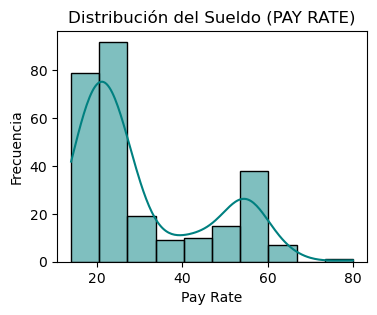

Tendencia: Se observa una concentración de sueldos en los rangos iniciales y medios, con una cola hacia los salarios más altos.



C:\Users\lorre\AppData\Local\Temp\ipykernel_8636\3508918312.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=CORE_train_procesado['PERFORMANCE SCORE'], palette='viridis')


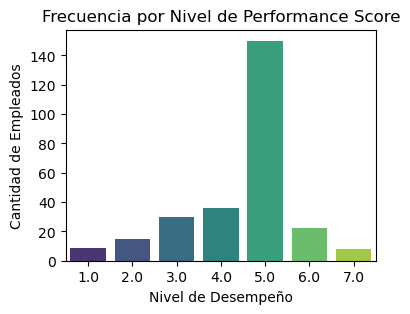

Tendencia: La gran mayoría de los colaboradores se agrupan en los niveles centrales de desempeño estándar o totalmente competente.


In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

print("==================================================")
print(" 1. ESTADÍSTICA DESCRIPTIVA CORE (Numéricas)")
print("==================================================")
display(CORE_train_procesado.describe())

print("\n==================================================")
print(" 2. CÁLCULO DE LA MODA CORE") 
print("==================================================")
display(CORE_train_procesado.mode().iloc[0])

print("\n==================================================")
print(" 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS CORE")
print("==================================================")
if 'SEX_F' in CORE_train_procesado.columns:
    print("Distribución de SEXO (One-Hot):")
    print(f" - Femenino (SEX_F = 1): {CORE_train_procesado['SEX_F'].sum()}")
    print(f" - Masculino (SEX_M = 1): {CORE_train_procesado['SEX_M'].sum()}")

if 'PERFORMANCE SCORE' in CORE_train_procesado.columns:
    print("\nConteo por nivel de PERFORMANCE SCORE (Escala ordinal 1 a 7):")
    print(CORE_train_procesado['PERFORMANCE SCORE'].value_counts().sort_index())

print("\n==================================================")
print(" 4. GRÁFICOS BÁSICOS Y TENDENCIAS CORE")
print("==================================================")

# Gráfica 1: Histograma de Pay Rate
plt.figure(figsize=(4, 3))
sns.histplot(CORE_train_procesado['PAY RATE'], kde=True, color='teal')
plt.title("Distribución del Sueldo (PAY RATE)")
plt.xlabel("Pay Rate")
plt.ylabel("Frecuencia")
plt.show()
print("Tendencia: Se observa una concentración de sueldos en los rangos iniciales y medios, con una cola hacia los salarios más altos.\n")

# Gráfica 2: Gráfico de barras para Performance Score
if 'PERFORMANCE SCORE' in CORE_train_procesado.columns:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=CORE_train_procesado['PERFORMANCE SCORE'], palette='viridis')
    plt.title("Frecuencia por Nivel de Performance Score")
    plt.xlabel("Nivel de Desempeño")
    plt.ylabel("Cantidad de Empleados")
    plt.show()
    print("Tendencia: La gran mayoría de los colaboradores se agrupan en los niveles centrales de desempeño estándar o totalmente competente.")

 1. ESTADÍSTICA DESCRIPTIVA (Numéricas - Retención)


,AGE,ATTRITION,DISTANCEFROMHOME,EDUCATION,ENVIRONMENTSATISFACTION,JOBINVOLVEMENT,JOBLEVEL,JOBSATISFACTION,MONTHLYINCOME,MONTHLYRATE,...,PERCENTSALARYHIKE,PERFORMANCERATING,RELATIONSHIPSATISFACTION,TOTALWORKINGYEARS,TRAININGTIMESLASTYEAR,WORKLIFEBALANCE,YEARSATCOMPANY,YEARSINCURRENTROLE,YEARSSINCELASTPROMOTION,YEARSWITHCURRMANAGER
count,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,...,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000
mean,36.900227,0.161754,9.203326,2.902494,2.710506,2.723356,2.049131,2.734694,6455.884354,14261.224490,...,15.218443,3.154951,2.702948,11.240363,2.804989,2.752079,6.981104,4.220711,2.167045,4.087680
std,9.155937,0.368364,8.120886,1.027762,1.091891,0.709109,1.111012,1.103521,4730.187266,7081.301311,...,3.664016,0.361995,1.084989,7.811488,1.292269,0.700487,6.134802,3.623920,3.197257,3.551206
min,18.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,...,11.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2865.000000,8042.500000,...,12.000000,3.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4834.000000,14218.000000,...,14.000000,3.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8230.500000,20406.000000,...,18.000000,3.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,2.000000,7.000000
max,60.000000,1.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,...,25.000000,4.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



 2. CÁLCULO DE LA MODA (Retención)


AGE                                             35
ATTRITION                                        0
BUSINESSTRAVEL                       TRAVEL_RARELY
DEPARTMENT                  RESEARCH & DEVELOPMENT
DISTANCEFROMHOME                                 2
EDUCATION                                        3
ENVIRONMENTSATISFACTION                          3
GENDER                                        MALE
JOBINVOLVEMENT                                   3
JOBLEVEL                                         1
JOBSATISFACTION                                  4
MONTHLYINCOME                                 2342
MONTHLYRATE                                   4223
NUMCOMPANIESWORKED                               1
OVERTIME                                         0
PERCENTSALARYHIKE                               11
PERFORMANCERATING                                3
RELATIONSHIPSATISFACTION                         3
TOTALWORKINGYEARS                               10
TRAININGTIMESLASTYEAR          


 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS
 GRÁFICO: EDAD (AGE) VS ATRICIÓN (ATTRITION)


C:\Users\lorre\AppData\Local\Temp\ipykernel_8636\2178654936.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


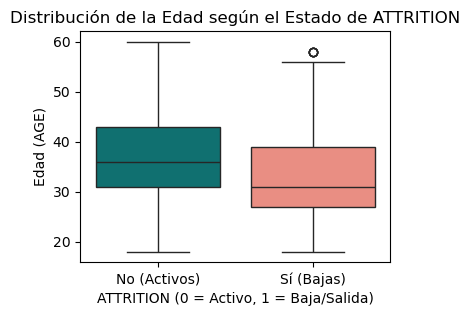

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt

print("==================================================")
print(" 1. ESTADÍSTICA DESCRIPTIVA (Numéricas - Retención)")
print("==================================================")
display(RET_train_procesado.describe())

print("\n==================================================")
print(" 2. CÁLCULO DE LA MODA (Retención)")
print("==================================================")
display(RET_train_procesado.mode().iloc[0])

print("\n==================================================")
print(" 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS")
print("==================================================")
# Ajusta según las columnas específicas de One-Hot o categóricas que tenga tu base de retención (ej. estado de salida, motivo, etc.)
for col in RET_train_procesado.columns:
    if RET_train_procesado[col].nunique() <= 5 and 'RET' in col.upper() or 'STATUS' in col.upper() or 'TERM' in col.upper():
        print(f"\nConteo para {col}:")
        print(RET_train_procesado[col].value_counts())


print('==================================================')
print(' GRÁFICO: EDAD (AGE) VS ATRICIÓN (ATTRITION)')
print('==================================================')

plt.figure(figsize=(4, 3))
sns.boxplot(
    data=RET_train_procesado, x='ATTRITION', y='AGE', palette=['teal', 'salmon']
)
plt.title('Distribución de la Edad según el Estado de ATTRITION')
plt.xlabel('ATTRITION (0 = Activo, 1 = Baja/Salida)')
plt.ylabel('Edad (AGE)')
plt.xticks([0, 1], ['No (Activos)', 'Sí (Bajas)'])
plt.show()


 1. ESTADÍSTICA DESCRIPTIVA (Numéricas - Ausentismo)


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
count,666.000000,664.000000,666.000000,666.000000,666.000000,660.000000,665.000000,663.000000,663.000000,660.000000,660.00000,657.000000,661.000000,664.000000,662.000000,665.000000,666.000000,652.000000,636.000000,644.000000
mean,18.174174,19.268072,6.274775,3.927928,2.522523,219.525758,29.536842,12.577677,36.520362,94.633333,0.05000,1.290715,0.996974,0.567771,0.069486,0.717293,79.085586,172.239264,26.683962,7.204969
std,11.037857,8.348037,3.468595,1.432460,1.107841,67.198035,14.823934,4.387525,6.542387,3.831280,0.21811,0.671131,1.092671,0.495759,0.254472,1.280561,13.060652,6.204982,4.356455,14.110371
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,81.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,10.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,93.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,2.000000,225.000000,26.000000,13.000000,37.000000,95.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.500000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,97.000000,0.00000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,100.000000,1.00000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000



 2. CÁLCULO DE LA MODA (Ausentismo)


ID                                       3
Reason for absence                    23.0
Month of absence                       3.0
Day of the week                          2
Seasons                                  2
Transportation expense               179.0
Distance from Residence to Work       26.0
Service time                          18.0
Age                                   28.0
Work load Average/day              222,196
Hit target                            99.0
Disciplinary failure                   0.0
Education                              1.0
Son                                    0.0
Social drinker                         1.0
Social smoker                          0.0
Pet                                    0.0
Weight                                89.0
Height                               170.0
Body mass index                       31.0
Absenteeism time in hours              8.0
Name: 0, dtype: object


 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS

Conteo para Day of the week:
Day of the week
2    145
3    139
4    135
6    134
5    113
Name: count, dtype: int64

Conteo para Seasons:
Seasons
2    181
4    171
3    160
1    154
Name: count, dtype: int64

Conteo para Disciplinary failure:
Disciplinary failure
0.0    627
1.0     33
Name: count, dtype: int64

Conteo para Education:
Education
1.0    543
3.0     71
2.0     40
4.0      3
Name: count, dtype: int64

Conteo para Son:
Son
0.0    271
1.0    208
2.0    132
4.0     37
3.0     13
Name: count, dtype: int64

Conteo para Social drinker:
Social drinker
1.0    377
0.0    287
Name: count, dtype: int64

Conteo para Social smoker:
Social smoker
0.0    616
1.0     46
Name: count, dtype: int64

Conteo para Pet:
Pet
0.0    422
1.0    118
2.0     85
4.0     29
8.0      6
5.0      5
Name: count, dtype: int64

 4. GRÁFICOS BÁSICOS Y DE DISTRIBUCIÓN (Ausentismo)
 GRÁFICO: DISTANCIA VS TIEMPO DE AUSENCIA


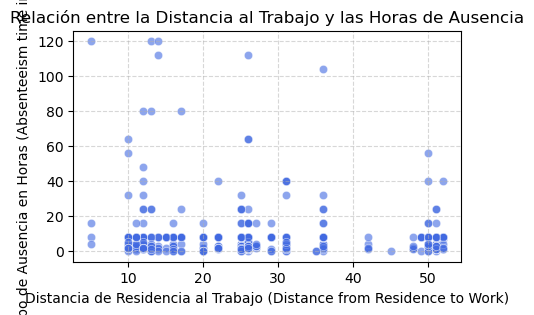

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns

print('==================================================')
print(' 1. ESTADÍSTICA DESCRIPTIVA (Numéricas - Ausentismo)')
print('==================================================')
display(AUS_train.describe())

print('\n==================================================')
print(' 2. CÁLCULO DE LA MODA (Ausentismo)')
print('==================================================')
display(AUS_train.mode().iloc[0])

print('\n==================================================')
print(' 3. CUENTAS (FRECUENCIAS) DE VARIABLES CODIFICADAS')
print('==================================================')
for col in AUS_train.columns:
  if AUS_train[col].nunique() <= 10:
    print(f'\nConteo para {col}:')
    print(AUS_train[col].value_counts())

print('\n==================================================')
print(' 4. GRÁFICOS BÁSICOS Y DE DISTRIBUCIÓN (Ausentismo)')
print('==================================================')

import matplotlib.pyplot as plt
import seaborn as sns

print('==================================================')
print(' GRÁFICO: DISTANCIA VS TIEMPO DE AUSENCIA')
print('==================================================')

plt.figure(figsize=(5, 3))
sns.scatterplot(
    data=AUS_train,
    x='Distance from Residence to Work',
    y='Absenteeism time in hours',
    color='royalblue',
    alpha=0.6,
)
plt.title(
    'Relación entre la Distancia al Trabajo y las Horas de Ausencia'
)
plt.xlabel('Distancia de Residencia al Trabajo (Distance from Residence to Work)')
plt.ylabel('Tiempo de Ausencia en Horas (Absenteeism time in hours)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

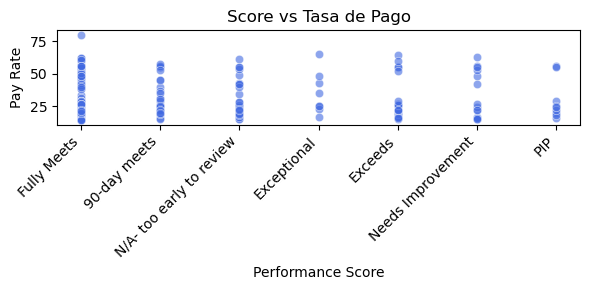

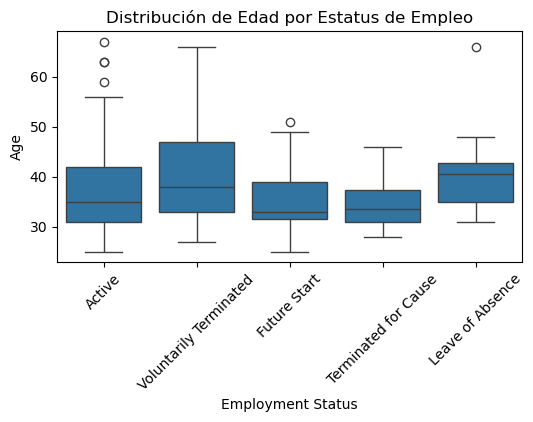

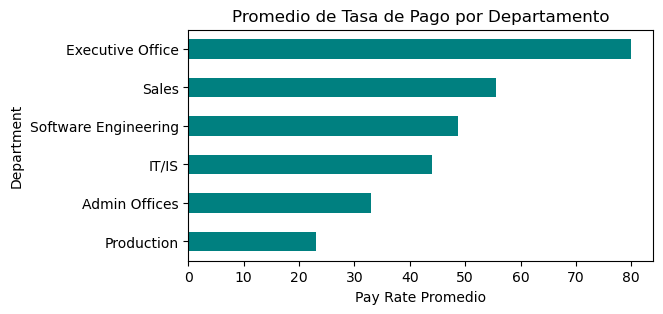

In [293]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CORE_train['Department'] = CORE_train['Department'].str.strip()

# 1. Asegurar formato de fechas si es necesario
CORE_train['Date of Hire'] = pd.to_datetime(
    CORE_train['Date of Hire'], errors='coerce'
)

# 2. Insight: Performance Score vs Tasa de Pago (Dispersión)
plt.figure(figsize=(6, 3))
sns.scatterplot(
    data=CORE_train,
    x='Performance Score',
    y='Pay Rate',
    color='royalblue',
    alpha=0.6,
)
plt.title('Score vs Tasa de Pago')
plt.xticks(rotation=45, ha='right')  # <- Esto rota y alinea las etiquetas
plt.tight_layout()
plt.show()

# 3. Insight 2: Edad según el Estatus de Empleo
plt.figure(figsize=(6, 3))
sns.boxplot(data=CORE_train, x='Employment Status', y='Age')
plt.title('Distribución de Edad por Estatus de Empleo')
plt.xticks(rotation=45)
plt.show()

# 4. Insight 3: Promedio de Pay Rate por Departamento
plt.figure(figsize=(6, 3))
CORE_train.groupby('Department')['Pay Rate'].mean().sort_values().plot(
    kind='barh', color='teal'
)
plt.title('Promedio de Tasa de Pago por Departamento')
plt.xlabel('Pay Rate Promedio')
plt.show()

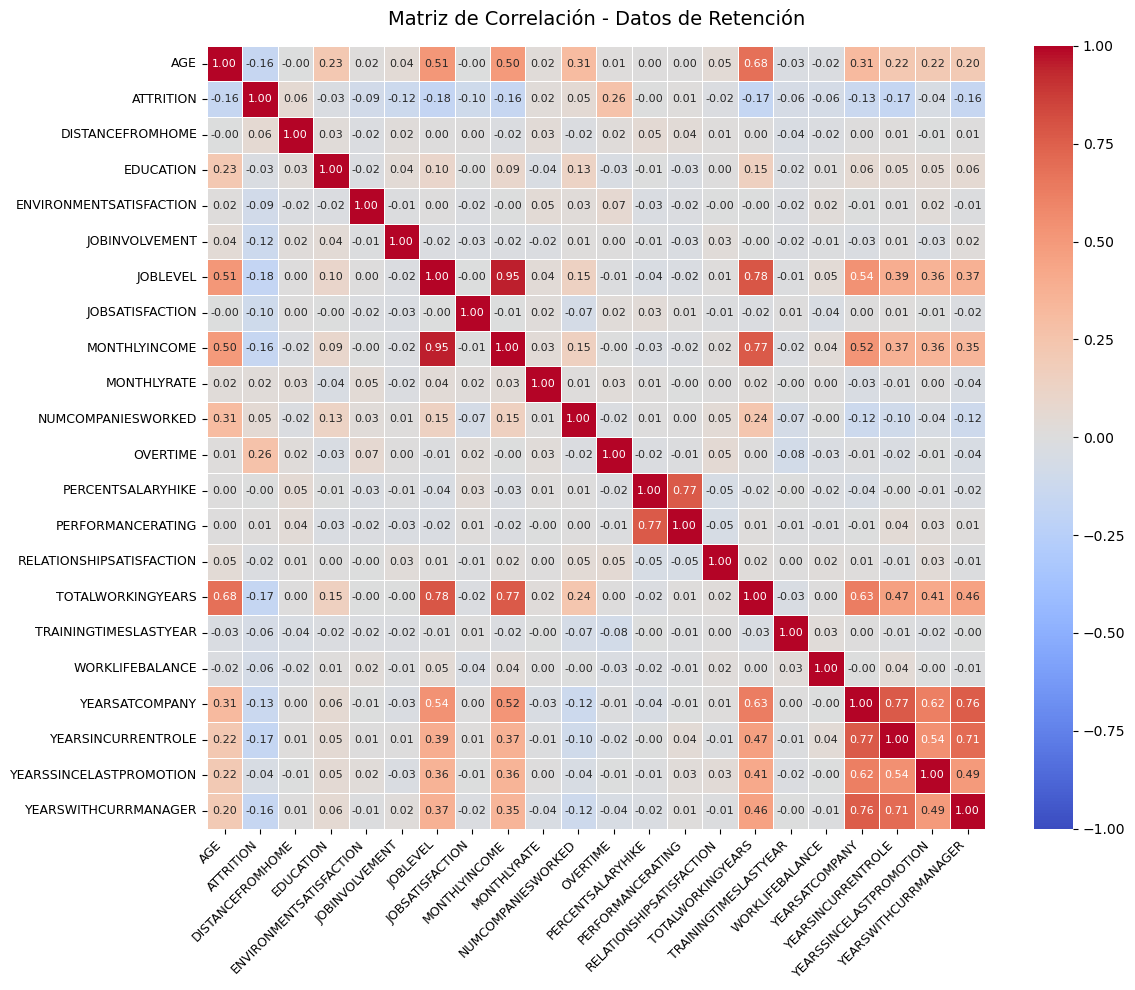

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar solo las columnas numéricas
RET_numeric = RET_train_procesado.select_dtypes(include=['float64', 'int64'])

# 2. Calcular la matriz de correlación
matriz_corr_ret = RET_numeric.corr()

# 3. Generar el mapa de calor con mejor tamaño y legibilidad
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr_ret,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 8}  # Ajusta el tamaño del texto para que no se encime
)

plt.title('Matriz de Correlación - Datos de Retención', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

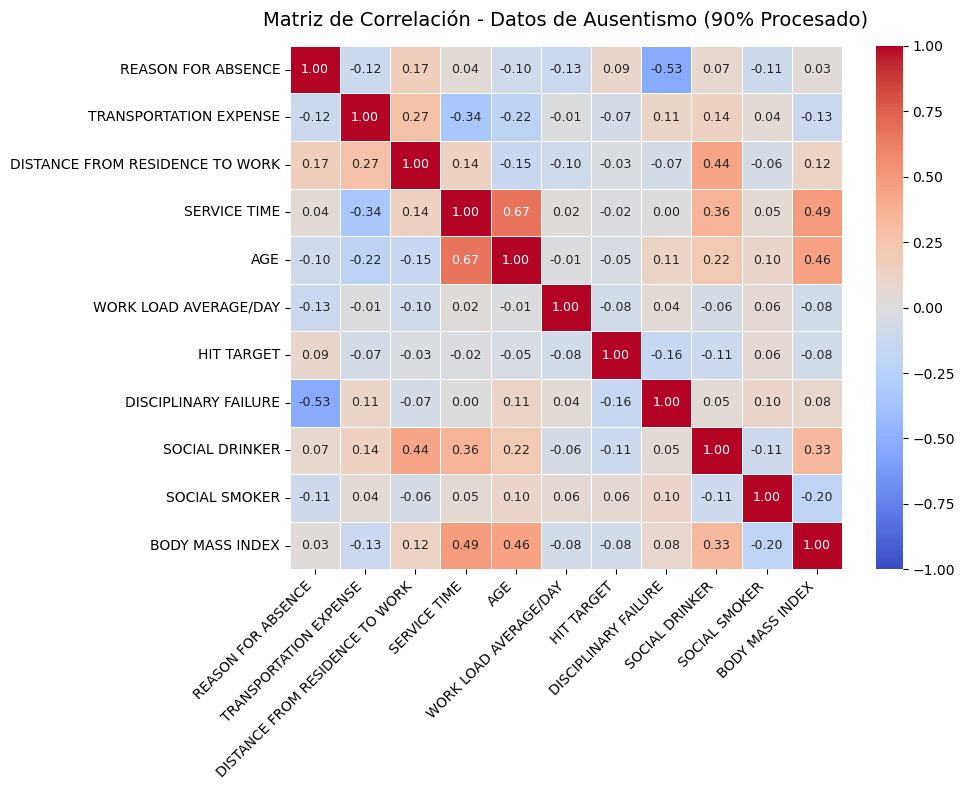

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar solo las columnas numéricas del 90% procesado de ausentismo
AUS_numeric = AUS_train_procesado.select_dtypes(include=['float64', 'int64'])

# 2. Calcular la matriz de correlación de Pearson
matriz_corr_aus = AUS_numeric.corr()

# 3. Generar el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr_aus,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 9}
)

plt.title('Matriz de Correlación - Datos de Ausentismo (90% Procesado)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()